# Vlasov-Poisson Data Exploration

This notebook explores the Vlasov-Poisson simulation data.

In [1]:
import os
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

## Data Structure Overview

In [2]:
data_dir = Path("../data")
print(f"Data directory: {data_dir.absolute()}")
print(f"\nContents:")
for item in sorted(data_dir.rglob("*")):
    if item.is_dir():
        print(f"  {item.relative_to(data_dir)}/")
    elif item.is_file():
        print(f"  {item.relative_to(data_dir)}")

Data directory: /home/abel-sr/Documentos/Deep-Learning/nops.worktrees/agents-vlasov-poisson-experiment-folder/experiments/vlasov-poisson/notebooks/../data

Contents:
  simulations/
  simulations/gabriela/
  simulations/gabriela/density/
  simulations/gabriela/density/index.csv
  simulations/gabriela/density/metadata.json
  simulations/gabriela/density/pairs.csv
  simulations/gabriela/density/z_0.1.npy
  simulations/gabriela/density/z_0.25.npy
  simulations/gabriela/density/z_0.5.npy
  simulations/gabriela/density/z_0.75.npy
  simulations/gabriela/density/z_0.npy
  simulations/gabriela/density/z_1.npy
  simulations/gabriela/density/z_10.npy
  simulations/gabriela/density/z_100.npy
  simulations/gabriela/density/z_125.npy
  simulations/gabriela/density/z_126.npy
  simulations/gabriela/density/z_127.npy
  simulations/gabriela/density/z_2.npy
  simulations/gabriela/density/z_25.npy
  simulations/gabriela/density/z_3.npy
  simulations/gabriela/density/z_4.npy
  simulations/gabriela/density/

## Load and Inspect Sample Data

In [3]:
# Find the simulations directory
simulations_dir = data_dir / "simulations" / "miguel_64"
density_dir = simulations_dir / "density"

print(f"Simulations directory: {simulations_dir}")
print(f"Density files found: {len(list(density_dir.glob('*.npy')))}")

# Get list of all density files
density_files = sorted(density_dir.glob("*.npy"))
print(f"\nFirst 5 files:")
for f in density_files[:5]:
    print(f"  {f.name}")

Simulations directory: ../data/simulations/miguel_64
Density files found: 1213

First 5 files:
  z_0.0003499999875202775.npy
  z_0.0035800000187009573.npy
  z_0.006819999776780605.npy
  z_0.01006999984383583.npy
  z_0.013330000452697277.npy


In [4]:
# Load a sample density file
sample_file = density_files[0]
sample_data = np.load(sample_file)

print(f"Sample file: {sample_file.name}")
print(f"Shape: {sample_data.shape}")
print(f"Data type: {sample_data.dtype}")
print(f"Min: {sample_data.min():.6f}")
print(f"Max: {sample_data.max():.6f}")
print(f"Mean: {sample_data.mean():.6f}")
print(f"Std: {sample_data.std():.6f}")

Sample file: z_0.0003499999875202775.npy
Shape: (64, 64, 64)
Data type: float32
Min: 0.000000
Max: 353.812744
Mean: 1.000000
Std: 4.166824


## Visualize Sample Density Field

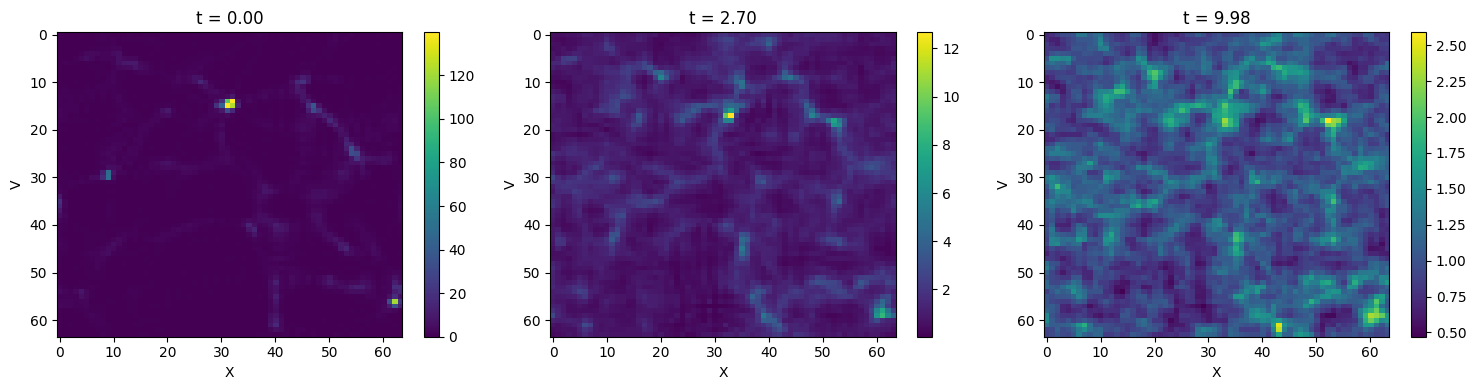

Timesteps visualized: [0.0003499999875202775, 2.704740047454834, 9.983229637145996]


In [6]:
# Plot the sample density
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Load first, middle, and last files
indices = [0, len(density_files)//2, len(density_files)-1]
timesteps = []

for i, idx in enumerate(indices):
    file = density_files[idx]
    data = np.load(file)
    
    # Extract timestep from filename (z_*.npy)
    timestep = float(file.stem.split("_")[1])
    timesteps.append(timestep)
    
    data = data[:, :, 0]
    
    im = axes[i].imshow(data, cmap="viridis", aspect="auto")
    axes[i].set_title(f"t = {timestep:.2f}")
    axes[i].set_xlabel("X")
    axes[i].set_ylabel("V")
    plt.colorbar(im, ax=axes[i])

plt.tight_layout()
plt.savefig("../results/density_visualization.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Timesteps visualized: {timesteps}")

## Temporal Evolution Analysis

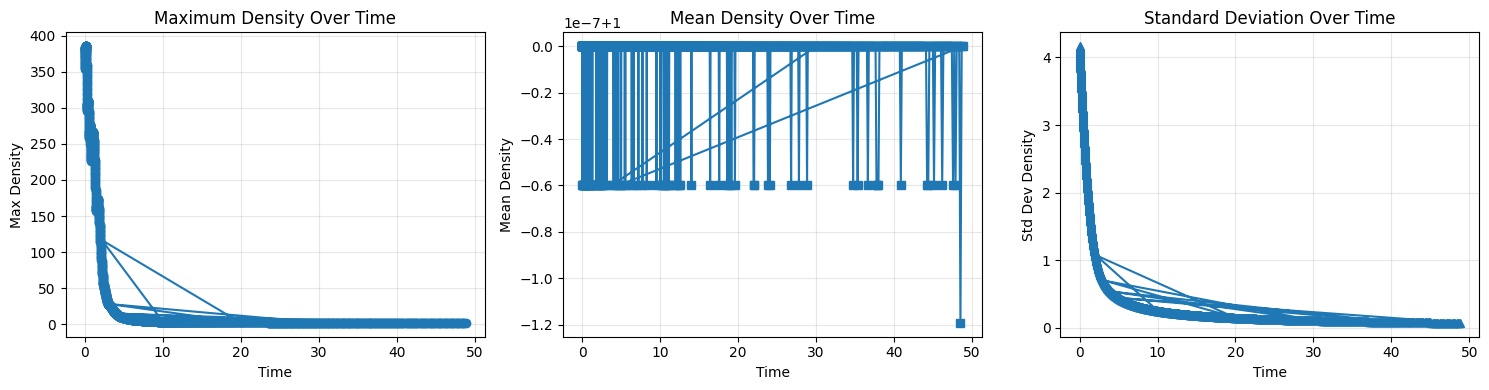

Total timesteps: 1213
Time range: [0.0003, 48.8390]


In [7]:
# Analyze how data evolves over time
timesteps = []
max_values = []
mean_values = []
std_values = []

for file in density_files:
    timestep = float(file.stem.split("_")[1])
    data = np.load(file)
    
    timesteps.append(timestep)
    max_values.append(data.max())
    mean_values.append(data.mean())
    std_values.append(data.std())

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(timesteps, max_values, 'o-')
axes[0].set_xlabel("Time")
axes[0].set_ylabel("Max Density")
axes[0].set_title("Maximum Density Over Time")
axes[0].grid(True, alpha=0.3)

axes[1].plot(timesteps, mean_values, 's-')
axes[1].set_xlabel("Time")
axes[1].set_ylabel("Mean Density")
axes[1].set_title("Mean Density Over Time")
axes[1].grid(True, alpha=0.3)

axes[2].plot(timesteps, std_values, '^-')
axes[2].set_xlabel("Time")
axes[2].set_ylabel("Std Dev Density")
axes[2].set_title("Standard Deviation Over Time")
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("../results/temporal_evolution.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Total timesteps: {len(timesteps)}")
print(f"Time range: [{min(timesteps):.4f}, {max(timesteps):.4f}]")

## Data Summary

In [8]:
print(f"Data Summary:")
print(f"=============")
print(f"Number of timesteps: {len(density_files)}")
print(f"Data shape: {sample_data.shape}")
print(f"Data type: {sample_data.dtype}")
print(f"Time range: [{min(timesteps):.4f}, {max(timesteps):.4f}]")
print(f"\nGlobal statistics across all timesteps:")
print(f"  Max density: {max(max_values):.6f}")
print(f"  Min density: {min([np.load(f).min() for f in density_files]):.6f}")
print(f"  Mean density: {np.mean(mean_values):.6f}")
print(f"  Std dev: {np.mean(std_values):.6f}")

Data Summary:
Number of timesteps: 1213
Data shape: (64, 64, 64)
Data type: float32
Time range: [0.0003, 48.8390]

Global statistics across all timesteps:
  Max density: 385.788116
  Min density: 0.000000
  Mean density: 1.000000
  Std dev: 0.953515
